<a href="https://colab.research.google.com/github/SanteriVtj/Julia-testing/blob/main/ReinforcementLearningnTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
using Pkg
Pkg.add("ReinforcementLearning")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [2]:
using ReinforcementLearning, Base

In [29]:
env = RandomWalk1D()

# RandomWalk1D

## Traits

| Trait Type        |                Value |
|:----------------- | --------------------:|
| NumAgentStyle     |        SingleAgent() |
| DynamicStyle      |         Sequential() |
| InformationStyle  | PerfectInformation() |
| ChanceStyle       |      Deterministic() |
| RewardStyle       |     TerminalReward() |
| UtilityStyle      |         GeneralSum() |
| ActionStyle       |   MinimalActionSet() |
| StateStyle        | Observation{Int64}() |
| DefaultStateStyle | Observation{Int64}() |
| EpisodeStyle      |           Episodic() |

## Is Environment Terminated?

No

## State Space

`Base.OneTo(7)`

## Action Space

`Base.OneTo(2)`

## Current State

```
4
```


In [30]:
S = state_space(env)

Base.OneTo(7)

In [31]:
s = state(env)

4

In [32]:
A = action_space(env)

Base.OneTo(2)

In [33]:
while true
  act!(env,rand(A))
  is_terminated(env) && break
end

In [35]:
NS = length(S)
NA = length(A)
policy = QBasedPolicy(
  learner = TDLearner(
    TabularQApproximator(
      n_state=NS,
      n_action=NA,
    ),
    :SARS
  ),
  explorer = EpsilonGreedyExplorer(.1)
)

QBasedPolicy(
  TDLearner(
    TabularQApproximator{Matrix{Float64}}([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]),  # 14 parameters  (all zero)
    1.0,
    0.01,
    0,
  ),
) 

In [15]:
run(
  policy,
  env,
  StopAfterNEpisodes(10),
  TotalRewardPerEpisode()
)

TotalRewardPerEpisode{Val{true}, Float64}([-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0], 0.0, true)

In [17]:
trajectory = Trajectory(
  ElasticArraySARTSTraces(;
    state = Int64 => (),
    action = Int64 => (),
    reward = Float64 => (),
    terminal = Bool => (),
  ),
  DummySampler(),
  InsertSampleRatioController()
)

Trajectory{EpisodesBuffer{(:state, :next_state, :action, :reward, :terminal), Tuple{Int64, Int64, Trace{ElasticArrays.ElasticVector{Int64, Vector{Int64}}, SubArray{Int64, 0, ElasticArrays.ElasticVector{Int64, Vector{Int64}}, Tuple{Int64}, true}}, Trace{ElasticArrays.ElasticVector{Float64, Vector{Float64}}, SubArray{Float64, 0, ElasticArrays.ElasticVector{Float64, Vector{Float64}}, Tuple{Int64}, true}}, Trace{ElasticArrays.ElasticVector{Bool, Vector{Bool}}, SubArray{Bool, 0, ElasticArrays.ElasticVector{Bool, Vector{Bool}}, Tuple{Int64}, true}}}, ElasticArraySARTSTraces{Tuple{MultiplexTraces{(:state, :next_state), Trace{ElasticArrays.ElasticVector{Int64, Vector{Int64}}, SubArray{Int64, 0, ElasticArrays.ElasticVector{Int64, Vector{Int64}}, Tuple{Int64}, true}}, Int64}, Trace{ElasticArrays.ElasticVector{Int64, Vector{Int64}}, SubArray{Int64, 0, ElasticArrays.ElasticVector{Int64, Vector{Int64}}, Tuple{Int64}, true}}, Trace{ElasticArrays.ElasticVector{Float64, Vector{Float64}}, SubArray{Floa

In [18]:
agent = Agent(
  policy = RandomPolicy(),
  trajectory = trajectory
)

Agent(
  RandomPolicy{Nothing, Random.TaskLocalRNG}(nothing, Random.TaskLocalRNG()),
) 

In [19]:
run(
  agent,
  env,
  StopAfterNEpisodes(10),
  TotalRewardPerEpisode()
)

TotalRewardPerEpisode{Val{true}, Float64}([-1.0, 1.0, 1.0, -1.0, -1.0, -1.0, 1.0, -1.0, -1.0, 1.0], 0.0, true)

In [3]:
Base.@kwdef mutable struct LotteryEnv <: AbstractEnv
  reward::Union{Nothing, Int} = nothing
end

LotteryEnv

In [5]:
struct LotteryAction{a}
  function LotteryAction(a)
    new{a}()
  end
end
RLBase.action_space(env::LotteryEnv) = LotteryAction.([:PowerRich, :MegaHaul, nothing])

In [6]:
RLBase.reward(env::LotteryEnv) = env.reward
RLBase.state(env::LotteryEnv, ::Observation, ::DefaultPlayer) = !isnothing(env.reward)
RLBase.state_space(env::LotteryEnv) = [false, true]
RLBase.is_terminated(env::LotteryEnv) = !isnothing(env.reward)
RLBase.reset!(env::LotteryEnv) = env.reward = nothing

In [7]:
function RLBase.act!(x::LotteryEnv, action)
  if action == LotteryAction(:PowerRich)
    x.reward = rand() < .01 ? 100_000_000 : -10
  elseif action == LotteryAction(:MegaHaul)
    x.reward = rand() < .05 ? 1_000_000 : -10
  elseif action == LotteryAction(nothing)
    x.reward = 0
  end
end

In [8]:
env = LotteryEnv()

# LotteryEnv

## Traits

| Trait Type        |                  Value |
|:----------------- | ----------------------:|
| NumAgentStyle     |          SingleAgent() |
| DynamicStyle      |           Sequential() |
| InformationStyle  | ImperfectInformation() |
| ChanceStyle       |           Stochastic() |
| RewardStyle       |           StepReward() |
| UtilityStyle      |           GeneralSum() |
| ActionStyle       |     MinimalActionSet() |
| StateStyle        |     Observation{Any}() |
| DefaultStateStyle |     Observation{Any}() |
| EpisodeStyle      |             Episodic() |

## Is Environment Terminated?

No

## State Space

`Bool[0, 1]`

## Action Space

`LotteryAction[LotteryAction{:PowerRich}(), LotteryAction{:MegaHaul}(), LotteryAction{nothing}()]`

## Current State

```
false
```


In [9]:
RLBase.test_runnable!(env)

Test Summary:                 | Pass  Total  Time
random policy with LotteryEnv | 2000   2000  0.2s


Test.DefaultTestSet("random policy with LotteryEnv", Any[], 2000, false, false, true, 1.741974747072168e9, 1.741974747293598e9, false, "/root/.julia/packages/ReinforcementLearningBase/bZTn5/src/base.jl")

In [11]:
for _ in 1:10
  reset!(env)
  while !is_terminated(env)
    action = rand(action_space(env))
    act!(env,action)
  end
end

In [12]:
run(RandomPolicy(action_space(env)), env,StopAfterNEpisodes(1_000))

EmptyHook()

In [13]:
hook = TotalRewardPerEpisode()
run(RandomPolicy(action_space(env)), env,StopAfterNEpisodes(1_000), hook)

TotalRewardPerEpisode{Val{true}, Float64}([-10.0, 0.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, 0.0, -10.0  …  0.0, 0.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, 0.0, 0.0], 0.0, true)

In [14]:
Pkg.add("Plots")
using Plots

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


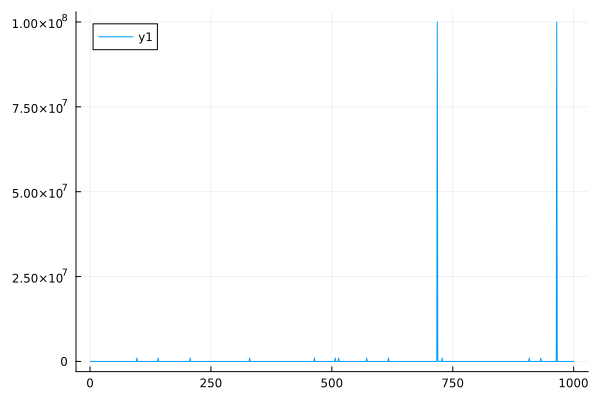

In [15]:
plot(hook.rewards)

In [19]:
p = QBasedPolicy(
  learner = TDLearner(
    TabularQApproximator(
      n_state = length(state_space(env)),
      n_action = length(action_space(env))
    ),
    :SARS
  ),
  explorer = EpsilonGreedyExplorer(.1)
)

QBasedPolicy(
  TDLearner(
    TabularQApproximator{Matrix{Float64}}([0.0 0.0; 0.0 0.0; 0.0 0.0]),  # 6 parameters  (all zero)
    1.0,
    0.01,
    0,
  ),
) 

In [21]:
wrapped_env = ActionTransformedEnv(
  StateTransformedEnv(
    env;
    state_mapping = s -> s ? 1 : 2,
    state_space_mapping = _ -> Base.OneTo(2)
  );
  action_mapping = i -> action_space(env)[i],
  action_space_mapping = _ -> Base.OneTo(3)
)

# LotteryEnv |> StateTransformedEnv |> ActionTransformedEnv

## Traits

| Trait Type        |                  Value |
|:----------------- | ----------------------:|
| NumAgentStyle     |          SingleAgent() |
| DynamicStyle      |           Sequential() |
| InformationStyle  | ImperfectInformation() |
| ChanceStyle       |           Stochastic() |
| RewardStyle       |           StepReward() |
| UtilityStyle      |           GeneralSum() |
| ActionStyle       |     MinimalActionSet() |
| StateStyle        |     Observation{Any}() |
| DefaultStateStyle |     Observation{Any}() |
| EpisodeStyle      |             Episodic() |

## Is Environment Terminated?

Yes

## State Space

`Base.OneTo(2)`

## Action Space

`Base.OneTo(3)`

## Current State

```
1
```


In [22]:
plan!(p, wrapped_env)

1

In [27]:
h = TotalRewardPerEpisode()
run(p, wrapped_env, StopAfterNEpisodes(1000), h)

TotalRewardPerEpisode{Val{true}, Float64}([0.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0  …  -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0, -10.0], 0.0, true)

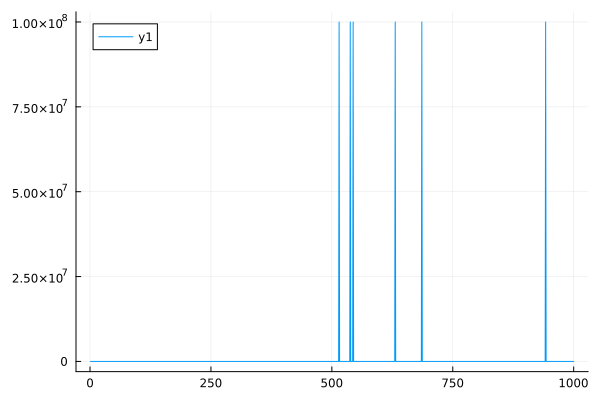

In [28]:
plot(h.rewards)